<a href="https://colab.research.google.com/github/romeurf/DipRadar/blob/main/colab_bootstrap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎯 DipRadar — Bootstrap ML v3 (Colab)

Pipeline completo de treino do modelo de **regressão v3** (substituição do classificador binário antigo).

## O que este notebook faz

```
ml_training_merged.parquet          ← já existe no repo (price + fund merged)
        ↓
Fase A  — Calcular targets v3 (max_return_60d, max_drawdown_60d) via yfinance
        ↓
Fase B  — Calcular features v3 extras (return_1m, sector_relative, beta_60d)
        ↓
dataset_v3.parquet                  ← dataset completo com targets + 24 features
        ↓
Fase C  — Walk-Forward CV (5 folds) — comparar XGB / LGBM / RF × v2/v3 features
        ↓
Fase D  — Treino final do champion no dataset completo
        ↓
dip_models_v3.pkl + ml_report_v3.json  ← guardar no Drive + deploy Railway
```

## Schema real do merged (17368 × 29)

| Grupo | Colunas |
|-------|---------|
| Meta | `ticker`, `symbol`, `alert_date`, `sector`, `price`, `entry_price` |
| Features base | `macro_score`, `vix`, `spy_drawdown_5d`, `sector_drawdown_5d`, `fcf_yield`, `revenue_growth`, `gross_margin`, `de_ratio`, `pe_vs_fair`, `analyst_upside`, `quality_score`, `drop_pct_today`, `drawdown_52w`, `rsi_14`, `atr_ratio`, `volume_spike`, `market_cap_b` |
| Features temporais (já no merged) | `return_3m`, `return_6m`, `spy_return_ref` |
| Labels | `outcome_label`, `label_win`, `label_further_drop` |
| Features novas (v3, calculadas) | `return_1m`, `sector_relative`, `beta_60d` |

## Plano de execução

| Fase | Células | Tempo estimado | Notas |
|------|---------|---------------|-------|
| Setup | 1–3 | 2 min | Drive, deps, repo |
| A — Targets | 4–5 | 20–40 min | 1 request yfinance/ticker |
| B — EDA | 6 | 2 min | diagnóstico dataset_v3 |
| C — Walk-Forward CV | 7–9 | 10–20 min | 6 modelos × 5 folds |
| D — Treino final | 10 | 5 min | champion no dataset completo |
| E — Guardar + Deploy | 11–13 | 2 min | Drive + Railway |

> ⚠️ **Cada sessão nova do Colab**: volta a correr as células 1–3 antes de continuar.
> O `dataset_v3.parquet` acumula no Google Drive — podes fechar entre sessões sem perder progresso.

---
## ⚙️ SETUP
---

## 1 · Montar Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_DIR = '/content/drive/MyDrive/DipRadar'
os.makedirs(DRIVE_DIR, exist_ok=True)
print(f'✅ Drive montado — {DRIVE_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive montado — /content/drive/MyDrive/DipRadar


## 2 · Instalar dependências

In [ ]:
%pip install -q yfinance scikit-learn pyarrow xgboost lightgbm scipy
print('✅ Dependências instaladas')

✅ Dependências instaladas


## 3 · Clonar / actualizar repositório e configurar paths

In [ ]:
import os, sys
from pathlib import Path

REPO_URL  = 'https://github.com/romeurf/DipRadar.git'
REPO_DIR  = Path('/content/DipRadar')
DRIVE_DIR = Path('/content/drive/MyDrive/DipRadar')

if REPO_DIR.exists():
    print('Repo já existe — a fazer pull...')
    !cd /content/DipRadar && git pull -q
else:
    print('A clonar repo...')
    !git clone -q {REPO_URL} /content/DipRadar

os.chdir(REPO_DIR)
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

PARQUET_MERGED = REPO_DIR / 'ml_training_merged.parquet'
PARQUET_V3     = DRIVE_DIR / 'dataset_v3.parquet'
MODEL_OUT      = DRIVE_DIR / 'dip_models_v3.pkl'
REPORT_OUT     = DRIVE_DIR / 'ml_report_v3.json'

assert PARQUET_MERGED.exists(), (
    f'❌ ml_training_merged.parquet não encontrado em {PARQUET_MERGED}\n'
    'Verifica que o repo foi clonado correctamente.'
)

print(f'\n✅ REPO_DIR          : {REPO_DIR}')
print(f'✅ ml_training_merged: {PARQUET_MERGED} ({PARQUET_MERGED.stat().st_size/1024:.0f} KB)')
print(f'📁 dataset_v3.parquet: {PARQUET_V3}')
!git log --oneline -1

Repo já existe — a fazer pull...

✅ REPO_DIR          : /content/DipRadar
✅ ml_training_merged: /content/DipRadar/ml_training_merged.parquet (801 KB)
📁 dataset_v3.parquet: /content/drive/MyDrive/DipRadar/dataset_v3.parquet
51daa33 (HEAD -> main, origin/main, origin/HEAD) fix(notebook): ajustar schema real do merged (symbol+ticker, return_3m/6m, market_cap_b)


---
## 📊 FASE A — Calcular Targets v3 + Features novas

O merged já tem `return_3m`, `return_6m` e `spy_return_ref`.
Esta fase calcula apenas o que **não existe** no merged:
- `max_return_60d` / `max_drawdown_60d` (targets de regressão, anti-leakage rigoroso)
- `return_1m` (retorno 21 dias antes do alerta, via preços históricos)
- `sector_relative` (return_1m do stock vs ETF de sector)
- `beta_60d` (OLS beta vs SPY nos 60 dias anteriores ao alerta)

> Tempo estimado: ~25–45 min para 762 tickers (1 request yfinance/ticker).
> Se a sessão expirar, volta a correr — o parquet acumula no Drive e os tickers já processados são saltados.
---

## 4 · Carregar merged + configurar parâmetros

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import time, pickle, json
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime
from scipy.stats import spearmanr
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import lightgbm as lgb

pd.set_option('display.float_format', '{:.4f}'.format)

# ── Parâmetros ────────────────────────────────────────────────────────
HORIZON_DAYS = 60
HISTORY_DAYS = 200
YF_SLEEP     = 0.35
WINSOR_PCT   = 0.01
TOP_K        = 0.20

SECTOR_ETF = {
    'Technology': 'XLK', 'Healthcare': 'XLV',
    'Communication Services': 'XLC', 'Financial Services': 'XLF',
    'Financials': 'XLF', 'Consumer Cyclical': 'XLY',
    'Consumer Defensive': 'XLP', 'Industrials': 'XLI',
    'Energy': 'XLE', 'Utilities': 'XLU',
    'Real Estate': 'XLRE', 'Basic Materials': 'XLB',
    'Materials': 'XLB',
}
DEFAULT_ETF = 'SPY'

# ── Carregar merged ───────────────────────────────────────────────────
df_merged = pd.read_parquet(PARQUET_MERGED)

# Schema real: o merged tem AMBAS 'ticker' e 'symbol' — usar 'ticker' como canónico
if 'ticker' not in df_merged.columns and 'symbol' in df_merged.columns:
    df_merged['ticker'] = df_merged['symbol']

# Detectar colunas de data e preço
date_col   = next((c for c in ['alert_date', 'date_iso', 'date'] if c in df_merged.columns), None)
price_col  = next((c for c in ['entry_price', 'price', 'close'] if c in df_merged.columns), None)
sector_col = 'sector' if 'sector' in df_merged.columns else None

assert date_col,  f'❌ Coluna de data não encontrada. Colunas: {list(df_merged.columns)}'
assert price_col, f'❌ Coluna de preço não encontrada. Colunas: {list(df_merged.columns)}'
assert 'ticker' in df_merged.columns, f'❌ Coluna ticker/symbol não encontrada.'

df_merged['alert_date']  = pd.to_datetime(df_merged[date_col], errors='coerce')
df_merged['ticker']      = df_merged['ticker'].astype(str).str.strip().str.upper()
df_merged['entry_price'] = pd.to_numeric(df_merged[price_col], errors='coerce')
df_merged['sector']      = df_merged[sector_col].fillna('Unknown') if sector_col else 'Unknown'
df_merged = df_merged.dropna(subset=['alert_date', 'ticker', 'entry_price'])
df_merged = df_merged.sort_values('alert_date').reset_index(drop=True)

# ── Features base (numéricas do merged, excluindo meta/labels) ────────
META_COLS  = ['alert_date', 'ticker', 'symbol', 'sector', 'price', 'entry_price']
LABEL_COLS = [c for c in ['outcome_label', 'label_win', 'label_further_drop']
              if c in df_merged.columns]
FEAT_COLS_MERGED = [
    c for c in df_merged.columns
    if c not in META_COLS + LABEL_COLS
    and pd.api.types.is_numeric_dtype(df_merged[c])
]

# ── Remover colunas com leakage (retornos futuros confirmados) ────────
# return_3m, return_6m, spy_return_ref têm valores futuros no merged
# → serão substituídas pelas versões históricas calculadas na célula 5
LEAKY_COLS = ['return_3m', 'return_6m', 'spy_return_ref']
FEAT_COLS_MERGED = [c for c in FEAT_COLS_MERGED if c not in LEAKY_COLS]

# ── Features novas v3 (calculadas via yfinance, célula 5) ─────────────
# Substituem as leaky + adicionam momentum e beta
# Nomes distintos (_hist) para evitar qualquer colisão futura
MOMENTUM_FEATURES = [
    'return_1m',           # retorno 22 dias antes do alerta
    'return_3m_hist',      # retorno 63 dias antes  (substitui return_3m leaky)
    'return_6m_hist',      # retorno 126 dias antes (substitui return_6m leaky)
    'spy_return_ref_hist', # retorno SPY 63 dias antes (substitui spy_return_ref leaky)
    'sector_relative',     # return_1m stock vs ETF sector
    'beta_60d',            # OLS beta vs SPY 60 dias
]

# ── Sumário ───────────────────────────────────────────────────────────
print(f'Shape merged       : {df_merged.shape}')
print(f'Período            : {df_merged["alert_date"].min().date()} → {df_merged["alert_date"].max().date()}')
print(f'Tickers únicos     : {df_merged["ticker"].nunique()}')
print(f'Features base      : {len(FEAT_COLS_MERGED)} → {FEAT_COLS_MERGED}')
print(f'Features v3 novas  : {MOMENTUM_FEATURES}')
print(f'Labels presentes   : {LABEL_COLS}')
print(f'\nTotal features no dataset_v3: {len(FEAT_COLS_MERGED) + len(MOMENTUM_FEATURES)}')
print(f'  ({len(FEAT_COLS_MERGED)} base  +  {len(MOMENTUM_FEATURES)} v3 calculadas)')

Shape merged       : (17368, 29)
Período            : 2006-05-19 → 2026-01-13
Tickers únicos     : 762
Features base      : 17 → ['macro_score', 'vix', 'spy_drawdown_5d', 'sector_drawdown_5d', 'fcf_yield', 'revenue_growth', 'gross_margin', 'de_ratio', 'pe_vs_fair', 'analyst_upside', 'quality_score', 'drop_pct_today', 'drawdown_52w', 'rsi_14', 'atr_ratio', 'volume_spike', 'market_cap_b']
Features v3 novas  : ['return_1m', 'return_3m_hist', 'return_6m_hist', 'spy_return_ref_hist', 'sector_relative', 'beta_60d']
Labels presentes   : ['outcome_label', 'label_win', 'label_further_drop']

Total features no dataset_v3: 23
  (17 base  +  6 v3 calculadas)


## 5 · Fetch preços + calcular targets e features v3

> Se o `dataset_v3.parquet` já existe no Drive, os tickers já calculados são saltados automaticamente.

In [ ]:
def fetch_ohlcv(ticker, start, end):
    try:
        df = yf.download(ticker, start=start, end=end, progress=False, auto_adjust=True)
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.droplevel(1)
        if df.index.tz is not None:
            df.index = df.index.tz_localize(None)
        return df if not df.empty else None
    except Exception:
        return None


def calc_targets(ohlcv, alert_date, entry_price, horizon=HORIZON_DAYS):
    """Anti-leakage: usa apenas preços APÓS alert_date."""
    future = ohlcv[
        (ohlcv.index > alert_date) &
        (ohlcv.index <= alert_date + pd.Timedelta(days=horizon + 5))
    ]['Close'].dropna()
    if len(future) < 5 or entry_price <= 0:
        return {'max_return_60d': np.nan, 'max_drawdown_60d': np.nan}
    returns = (future.values - entry_price) / entry_price
    return {'max_return_60d':   float(np.max(returns)),
            'max_drawdown_60d': float(np.percentile(returns, 10))}  # ← p10 em vez de min


def pct_ret(series, n_days):
    """Retorno dos últimos n_days numa série de preços. Retorna 0.0 se dados insuficientes."""
    s = series.dropna()
    n = min(n_days + 1, len(s))
    if n < 2:
        return 0.0
    return float((s.iloc[-1] / s.iloc[-n]) - 1)


def calc_momentum_features(hist, sec_hist, spy_hist):
    """Calcula 6 features v3 com dados ANTES do alert_date — zero leakage."""
    close = hist['Close'].dropna()
    default = {
        'return_1m':           0.0,
        'return_3m_hist':      0.0,
        'return_6m_hist':      0.0,
        'spy_return_ref_hist': 0.0,
        'sector_relative':     0.0,
        'beta_60d':            1.0,
    }
    if len(close) < 5:
        return default

    ret_1m = pct_ret(close, 22)    # ~1 mês
    ret_3m = pct_ret(close, 63)    # ~3 meses
    ret_6m = pct_ret(close, 126)   # ~6 meses

    # spy_return_ref_hist: retorno do SPY nos 63 dias antes do alerta
    spy_ret_hist = pct_ret(spy_hist['Close'], 63) if spy_hist is not None and len(spy_hist) >= 10 else 0.0

    # sector_relative: outperformance do stock vs ETF de sector no último mês
    sector_relative = 0.0
    if sec_hist is not None and len(sec_hist) >= 10:
        sector_relative = ret_1m - pct_ret(sec_hist['Close'], 22)

    # beta_60d: OLS beta vs SPY
    beta_60d = 1.0
    if spy_hist is not None and len(close) >= 20 and len(spy_hist) >= 20:
        n      = min(61, len(close), len(spy_hist))
        s_ret  = close.pct_change().dropna().iloc[-n:]
        m_ret  = spy_hist['Close'].dropna().pct_change().dropna().iloc[-n:]
        common = s_ret.index.intersection(m_ret.index)
        if len(common) >= 10:
            s, m = s_ret.loc[common].values, m_ret.loc[common].values
            cov  = np.cov(s, m)
            beta_60d = float(cov[0, 1] / cov[1, 1]) if cov[1, 1] > 0 else 1.0

    return {
        'return_1m':           ret_1m,
        'return_3m_hist':      ret_3m,
        'return_6m_hist':      ret_6m,
        'spy_return_ref_hist': spy_ret_hist,
        'sector_relative':     sector_relative,
        'beta_60d':            beta_60d,
    }


print('Helpers definidos ✅')

# ── Carregar progresso anterior ───────────────────────────────────────
done_keys = set()
rows_v3   = []

if PARQUET_V3.exists():
    df_existing = pd.read_parquet(PARQUET_V3)
    df_existing['alert_date'] = pd.to_datetime(df_existing['alert_date'])
    for _, r in df_existing.iterrows():
        done_keys.add((r['ticker'], r['alert_date'].date()))
    rows_v3 = df_existing.to_dict('records')
    print(f'✅ dataset_v3 carregado do Drive: {len(df_existing)} alertas já processados')
else:
    print('ℹ️  dataset_v3 não existe — a começar do zero.')

df_todo        = df_merged[~df_merged.apply(
    lambda r: (r['ticker'], r['alert_date'].date()) in done_keys, axis=1
)].copy()
unique_tickers = df_todo['ticker'].unique()
print(f'Alertas por processar       : {len(df_todo)} / {len(df_merged)}')
print(f'Tickers únicos por processar: {len(unique_tickers)}')

# ── Fetch ETFs (janela global, uma única vez) ─────────────────────────
global_start = (df_merged['alert_date'].min() - pd.Timedelta(days=HISTORY_DAYS)).strftime('%Y-%m-%d')
global_end   = (df_merged['alert_date'].max() + pd.Timedelta(days=HORIZON_DAYS + 10)).strftime('%Y-%m-%d')
etfs_needed  = list(set(
    [SECTOR_ETF.get(s, DEFAULT_ETF) for s in df_merged['sector'].unique()] + ['SPY']
))
print(f'\nJanela global : {global_start} → {global_end}')
print(f'ETFs a carregar: {sorted(etfs_needed)}')

etf_cache = {}
for etf in etfs_needed:
    etf_cache[etf] = fetch_ohlcv(etf, global_start, global_end)
    time.sleep(YF_SLEEP)
print(f'ETFs carregados: {sum(v is not None for v in etf_cache.values())}/{len(etf_cache)}')

Helpers definidos ✅
ℹ️  dataset_v3 não existe — a começar do zero.
Alertas por processar       : 17368 / 17368
Tickers únicos por processar: 762

Janela global : 2005-10-31 → 2026-03-24
ETFs a carregar: ['SPY', 'XLB', 'XLC', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLRE', 'XLU', 'XLV', 'XLY']
ETFs carregados: 12/12


In [ ]:
# ── Processar tickers ─────────────────────────────────────────────────
# Se a sessão expirar, volta a correr esta célula — retoma do ponto onde ficou.

SAVE_EVERY = 50
skipped    = 0
processed  = 0

def save_progress():
    if not rows_v3: return
    pd.DataFrame(rows_v3).to_parquet(PARQUET_V3, index=False)
    print(f'  💾 Guardado: {len(rows_v3)} alertas')

ticker_groups = df_todo.groupby('ticker')

for i, ticker in enumerate(unique_tickers, 1):
    if ticker not in ticker_groups.groups: continue
    group = ticker_groups.get_group(ticker)

    t_start = (group['alert_date'].min() - pd.Timedelta(days=HISTORY_DAYS)).strftime('%Y-%m-%d')
    t_end   = (group['alert_date'].max() + pd.Timedelta(days=HORIZON_DAYS + 10)).strftime('%Y-%m-%d')
    ohlcv   = fetch_ohlcv(ticker, t_start, t_end)
    time.sleep(YF_SLEEP)

    if ohlcv is None:
        skipped += len(group); continue

    for _, row in group.iterrows():
        alert_date  = pd.Timestamp(row['alert_date'])
        entry_price = float(row['entry_price'])
        sector      = row.get('sector', 'Unknown')
        etf         = SECTOR_ETF.get(sector, DEFAULT_ETF)

        hist = ohlcv[ohlcv.index <= alert_date]
        if len(hist) < 10: skipped += 1; continue

        tgt = calc_targets(ohlcv, alert_date, entry_price)
        if np.isnan(tgt['max_return_60d']): skipped += 1; continue

        # Features base do merged (point-in-time, sem recalcular)
        feat_base = {c: (float(row[c]) if pd.notna(row.get(c)) else 0.0)
                     for c in FEAT_COLS_MERGED}

        # Features novas v3
        spy_slice = (etf_cache['SPY'][etf_cache['SPY'].index <= alert_date]
                     if etf_cache.get('SPY') is not None else None)
        sec_slice = (etf_cache[etf][etf_cache[etf].index <= alert_date]
                     if etf_cache.get(etf) is not None else None)
        feat_mom = calc_momentum_features(hist, sec_slice, spy_slice)

        record = {
            'ticker':           ticker,
            'alert_date':       alert_date,
            'sector':           sector,
            'entry_price':      entry_price,
            **feat_base,
            **feat_mom,
            'max_return_60d':   tgt['max_return_60d'],
            'max_drawdown_60d': tgt['max_drawdown_60d'],
            'label_win':        int(row.get('label_win', row.get('outcome_label', 0))),
        }
        rows_v3.append(record)
        done_keys.add((ticker, alert_date.date()))
        processed += 1

    if i % 20 == 0:
        print(f'  [{i}/{len(unique_tickers)}] {ticker} — ok={processed} skip={skipped}')
    if i % SAVE_EVERY == 0:
        save_progress()

save_progress()

df_v3 = pd.read_parquet(PARQUET_V3)
df_v3['alert_date'] = pd.to_datetime(df_v3['alert_date'])
df_v3 = df_v3.sort_values('alert_date').reset_index(drop=True)

print(f'\n✅ Fase A concluída')
print(f'   Dataset v3 shape : {df_v3.shape}')
print(f'   Alertas saltados : {skipped}')
print(f'   Win rate         : {df_v3["label_win"].mean():.1%}')
print(f'   max_return_60d   : mean={df_v3["max_return_60d"].mean():.4f}  std={df_v3["max_return_60d"].std():.4f}')
print(f'   max_drawdown_60d : mean={df_v3["max_drawdown_60d"].mean():.4f}  std={df_v3["max_drawdown_60d"].std():.4f}')

  [20/762] RR.L — ok=460 skip=0
  [40/762] SHB-A.ST — ok=910 skip=0
  💾 Guardado: 1140 alertas
  [60/762] NDAQ — ok=1370 skip=0
  [80/762] ICE — ok=1830 skip=0
  [100/762] LRCX — ok=2290 skip=0
  💾 Guardado: 2290 alertas
  [120/762] ATO.PA — ok=2750 skip=0
  [140/762] BIIB — ok=3210 skip=0
  💾 Guardado: 3440 alertas
  [160/762] POOL — ok=3670 skip=0
  [180/762] MNST — ok=4130 skip=0
  [200/762] OXY — ok=4590 skip=0
  💾 Guardado: 4590 alertas
  [220/762] ADSK — ok=5050 skip=0
  [240/762] JBHT — ok=5510 skip=0
  💾 Guardado: 5740 alertas
  [260/762] DPZ — ok=5970 skip=0
  [280/762] FDX — ok=6430 skip=0
  [300/762] VTRS — ok=6890 skip=0
  💾 Guardado: 6890 alertas
  [320/762] DGX — ok=7348 skip=0
  [340/762] LR.PA — ok=7808 skip=0
  💾 Guardado: 8038 alertas
  [360/762] MA — ok=8267 skip=1
  [380/762] RCL — ok=8727 skip=1
  [400/762] AZO — ok=9180 skip=7
  💾 Guardado: 9180 alertas
  [420/762] QIA.DE — ok=9638 skip=7
  [440/762] UCB.BR — ok=10098 skip=7
  💾 Guardado: 10328 alertas
  [460/762]

ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: PHNX.L"}}}
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['PHNX.L']: YFTzMissingError('possibly delisted; no timezone found')


  [660/762] NXPI — ok=15092 skip=30
  [680/762] PANW — ok=15552 skip=30
  [700/762] NWS — ok=16012 skip=30
  💾 Guardado: 16012 alertas
  [720/762] LIGHT.AS — ok=16472 skip=30
  [740/762] PINS — ok=16928 skip=30
  💾 Guardado: 17154 alertas
  [760/762] SOLV — ok=17313 skip=30
  💾 Guardado: 17338 alertas

✅ Fase A concluída
   Dataset v3 shape : (17338, 30)
   Alertas saltados : 30
   Win rate         : 29.1%
   max_return_60d   : mean=1.7171  std=163.6284
   max_drawdown_60d : mean=-0.1232  std=0.1477


In [ ]:
# Após o loop da célula 5b, antes do save_progress() final:
# Adiciona estas linhas ao resultado final

df_v3 = pd.read_parquet(PARQUET_V3)
df_v3['alert_date'] = pd.to_datetime(df_v3['alert_date'])

# Remover alertas com entry_price claramente errado (< 0.50)
n_before = len(df_v3)
df_v3 = df_v3[df_v3['entry_price'] >= 0.50].copy()
print(f"Removidos por entry_price < 0.50: {n_before - len(df_v3)}")

# Winsorizar targets a [-95%, +200%] — hard cap razoável para 60 dias
df_v3['max_return_60d']   = df_v3['max_return_60d'].clip(-0.95, 2.00)
df_v3['max_drawdown_60d'] = df_v3['max_drawdown_60d'].clip(-0.95, 0.50)

# Verificar resultado
print(f"\nApós fix:")
print(f"  Shape            : {df_v3.shape}")
print(f"  max_return mean  : {df_v3['max_return_60d'].mean():.4f}  std={df_v3['max_return_60d'].std():.4f}")
print(f"  max_drawdown mean: {df_v3['max_drawdown_60d'].mean():.4f}  std={df_v3['max_drawdown_60d'].std():.4f}")
print(f"  Win rate (>0%)   : {(df_v3['max_return_60d'] > 0).mean():.1%}")
print(f"  Win rate (>5%)   : {(df_v3['max_return_60d'] > 0.05).mean():.1%}")

# Guardar versão limpa
df_v3.to_parquet(PARQUET_V3, index=False)
print(f"\n✅ dataset_v3 limpo guardado: {PARQUET_V3}")

Removidos por entry_price < 0.50: 35

Após fix:
  Shape            : (17303, 30)
  max_return mean  : 0.1428  std=0.1662
  max_drawdown mean: -0.1233  std=0.1436
  Win rate (>0%)   : 92.0%
  Win rate (>5%)   : 71.8%

✅ dataset_v3 limpo guardado: /content/drive/MyDrive/DipRadar/dataset_v3.parquet


In [ ]:
# Redefinir label_win com base nos targets calculados
# Critério: max_return_60d > 5% (retorno mínimo aceitável em 60 dias)
df_v3 = pd.read_parquet(PARQUET_V3)
df_v3['alert_date'] = pd.to_datetime(df_v3['alert_date'])

WIN_THRESHOLD = 0.05  # +5% em 60 dias
df_v3['label_win'] = (df_v3['max_return_60d'] > WIN_THRESHOLD).astype(int)

print(f"label_win redefinido (max_return_60d > {WIN_THRESHOLD:.0%}):")
print(f"  Win  : {df_v3['label_win'].sum():,}  ({df_v3['label_win'].mean():.1%})")
print(f"  Loss : {(df_v3['label_win']==0).sum():,}  ({1-df_v3['label_win'].mean():.1%})")

df_v3.to_parquet(PARQUET_V3, index=False)
print("✅ label_win actualizado e guardado")

label_win redefinido (max_return_60d > 5%):
  Win  : 12,418  (71.8%)
  Loss : 4,885  (28.2%)
✅ label_win actualizado e guardado


In [ ]:
df_v3 = pd.read_parquet(PARQUET_V3)
df_v3['alert_date'] = pd.to_datetime(df_v3['alert_date'])
df_v3 = df_v3.sort_values('alert_date').reset_index(drop=True)

---
## 📈 FASE B — EDA e validação do dataset_v3
---

## 6 · Diagnóstico do dataset_v3

Shape              : (17303, 30)
Período            : 2006-05-19 → 2026-01-13
Features totais    : 23
Features v3 novas  : ['return_1m', 'return_3m_hist', 'return_6m_hist', 'spy_return_ref_hist', 'sector_relative', 'beta_60d']

✅ Nenhum NaN nas features

Top 10 correlações Spearman com max_return_60d:
  atr_ratio                          : rho=+0.3644  p=0.0000  ***
  drawdown_52w                       : rho=-0.3034  p=0.0000  ***
  vix                                : rho=+0.2634  p=0.0000  ***
  volume_spike                       : rho=-0.2318  p=0.0000  ***
  spy_return_ref_hist                : rho=-0.2208  p=0.0000  ***
  return_3m_hist                     : rho=-0.2133  p=0.0000  ***
  return_6m_hist                     : rho=-0.2094  p=0.0000  ***
  macro_score                        : rho=-0.1881  p=0.0000  ***
  beta_60d                           : rho=+0.1291  p=0.0000  ***
  drop_pct_today                     : rho=-0.1170  p=0.0000  ***


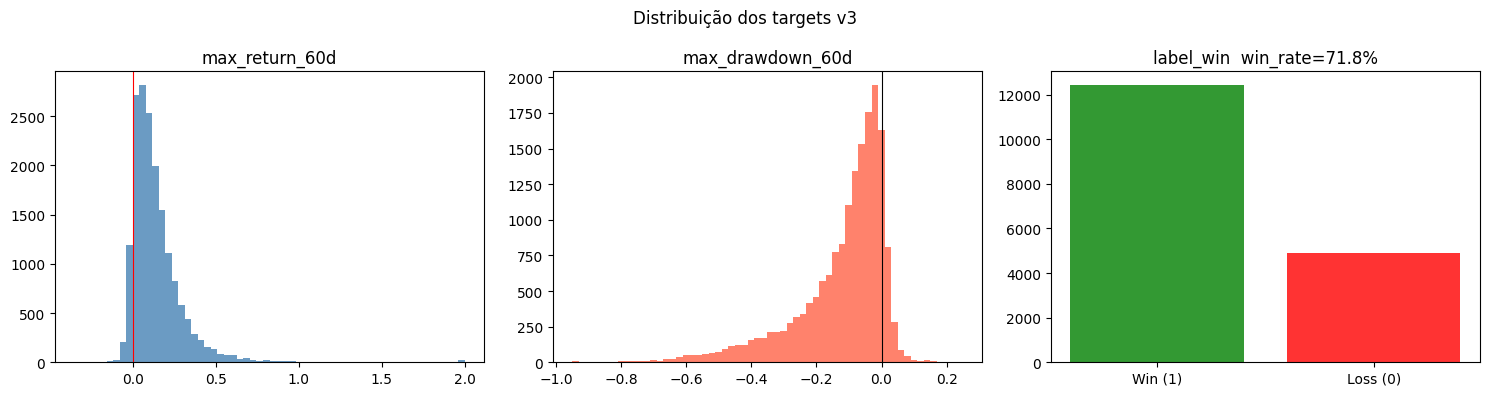

In [ ]:
# Recarregar se sessão foi retomada
if 'df_v3' not in dir():
    df_v3 = pd.read_parquet(PARQUET_V3)
    df_v3['alert_date'] = pd.to_datetime(df_v3['alert_date'])
    df_v3 = df_v3.sort_values('alert_date').reset_index(drop=True)

META    = ['ticker', 'alert_date', 'sector', 'entry_price']
TARGETS = ['max_return_60d', 'max_drawdown_60d', 'label_win']
FEATS   = [c for c in df_v3.columns
           if c not in META + TARGETS
           and pd.api.types.is_numeric_dtype(df_v3[c])]

print(f'Shape              : {df_v3.shape}')
print(f'Período            : {df_v3["alert_date"].min().date()} → {df_v3["alert_date"].max().date()}')
print(f'Features totais    : {len(FEATS)}')
print(f'Features v3 novas  : {[f for f in MOMENTUM_FEATURES if f in df_v3.columns]}')

# NaNs
nans = df_v3[FEATS].isna().sum()
nans_nonzero = nans[nans > 0]
if len(nans_nonzero):
    print('\n⚠️  NaNs (serão substituídos por 0 no treino):')
    print(nans_nonzero.to_string())
else:
    print('\n✅ Nenhum NaN nas features')

# Correlações Spearman com max_return_60d
print('\nTop 10 correlações Spearman com max_return_60d:')
corrs = {}
for f in FEATS:
    try:
        r, p = spearmanr(df_v3[f].fillna(0), df_v3['max_return_60d'])
        corrs[f] = (r, p)
    except Exception: pass
for feat, (r, p) in sorted(corrs.items(), key=lambda x: abs(x[1][0]), reverse=True)[:10]:
    star = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else '  '))
    print(f'  {feat:35s}: rho={r:+.4f}  p={p:.4f}  {star}')

# Distribuição dos targets
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(df_v3['max_return_60d'].dropna(), bins=60, color='steelblue', alpha=0.8)
axes[0].set_title('max_return_60d'); axes[0].axvline(0, color='red', lw=0.8)
axes[1].hist(df_v3['max_drawdown_60d'].dropna(), bins=60, color='tomato', alpha=0.8)
axes[1].set_title('max_drawdown_60d'); axes[1].axvline(0, color='black', lw=0.8)
axes[2].bar(['Win (1)', 'Loss (0)'],
            [df_v3['label_win'].sum(), (df_v3['label_win'] == 0).sum()],
            color=['green', 'red'], alpha=0.8)
axes[2].set_title(f'label_win  win_rate={df_v3["label_win"].mean():.1%}')
plt.suptitle('Distribuição dos targets v3', fontsize=12)
plt.tight_layout(); plt.show()

---
## 🔁 FASE C — Walk-Forward Cross-Validation

Expanding window: treina em tudo até ao corte, testa no período seguinte.
Compara **6 modelos**: XGBoost / LightGBM / RandomForest × features v2 (sem momentum) / v3 (com momentum).

Métricas:
- **Spearman rho**: correlação de rank entre score e max_return_60d real
- **Top-K P&L**: retorno médio real dos 20% alertas com score mais alto
---

## 7 · Definir modelos e métricas

In [ ]:
def winsorize(x, pct=WINSOR_PCT):
    lo, hi = np.percentile(x, pct * 100), np.percentile(x, (1 - pct) * 100)
    return np.clip(x, lo, hi)

def transform_targets(y_up, y_down):
    return np.log1p(np.clip(y_up, -0.5, 2.0)), -np.log1p(np.clip(-y_down, 0, 1.0))

def inverse_transform(yp_up, yp_down):
    return np.expm1(np.clip(yp_up, -3, 3)), -np.expm1(np.clip(-yp_down, 0, 3))

def spearman_metrics(pred_up, y_up, pred_down, y_down):
    r_up,  _ = spearmanr(pred_up,  y_up)
    r_dn,  _ = spearmanr(pred_down, y_down)
    return {'rho_up': r_up, 'rho_down': r_dn, 'rho_mean': (r_up + r_dn) / 2}

def topk_pnl(pred_up, pred_down, y_up_true, k=TOP_K):
    abs_down = np.abs(pred_down)
    score    = np.where(abs_down > 0, pred_up / abs_down, 0.0)
    n_top    = max(1, int(len(score) * k))
    return float(np.mean(y_up_true[np.argsort(score)[-n_top:]]))

# v2 = features base do merged; v3 = v2 + momentum calculado
FEATS_V2 = [f for f in FEATS if f not in MOMENTUM_FEATURES]
FEATS_V3 = FEATS

MODEL_CONFIGS = {
    'XGB-v2':  {'feat': FEATS_V2,
               'up':   lambda: XGBRegressor(n_estimators=400, max_depth=4, learning_rate=0.03, subsample=0.8, colsample_bytree=0.8, min_child_weight=3,  gamma=0.05, reg_alpha=0.1, reg_lambda=1.0, objective='reg:squarederror', random_state=42, n_jobs=-1, verbosity=0),
               'down': lambda: XGBRegressor(n_estimators=500, max_depth=4, learning_rate=0.025, subsample=0.7, colsample_bytree=0.7, min_child_weight=6, gamma=0.2,  reg_alpha=0.2, reg_lambda=1.5, objective='reg:squarederror', random_state=42, n_jobs=-1, verbosity=0)},
    'XGB-v3':  {'feat': FEATS_V3,
               'up':   lambda: XGBRegressor(n_estimators=400, max_depth=4, learning_rate=0.03, subsample=0.8, colsample_bytree=0.8, min_child_weight=3,  gamma=0.05, reg_alpha=0.1, reg_lambda=1.0, objective='reg:squarederror', random_state=42, n_jobs=-1, verbosity=0),
               'down': lambda: XGBRegressor(n_estimators=500, max_depth=4, learning_rate=0.025, subsample=0.7, colsample_bytree=0.7, min_child_weight=6, gamma=0.2,  reg_alpha=0.2, reg_lambda=1.5, objective='reg:squarederror', random_state=42, n_jobs=-1, verbosity=0)},
    'LGBM-v2': {'feat': FEATS_V2,
               'up':   lambda: lgb.LGBMRegressor(n_estimators=500, max_depth=4, learning_rate=0.025, subsample=0.8, colsample_bytree=0.8, min_child_samples=20, reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1, verbose=-1),
               'down': lambda: lgb.LGBMRegressor(n_estimators=600, max_depth=4, learning_rate=0.02,  subsample=0.7, colsample_bytree=0.7, min_child_samples=30, reg_alpha=0.2, reg_lambda=1.5, random_state=42, n_jobs=-1, verbose=-1)},
    'LGBM-v3': {'feat': FEATS_V3,
               'up':   lambda: lgb.LGBMRegressor(n_estimators=500, max_depth=4, learning_rate=0.025, subsample=0.8, colsample_bytree=0.8, min_child_samples=20, reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1, verbose=-1),
               'down': lambda: lgb.LGBMRegressor(n_estimators=600, max_depth=4, learning_rate=0.02,  subsample=0.7, colsample_bytree=0.7, min_child_samples=30, reg_alpha=0.2, reg_lambda=1.5, random_state=42, n_jobs=-1, verbose=-1)},
    'RF-v2': {'feat': FEATS_V2,
              'up':   lambda: RandomForestRegressor(n_estimators=200, max_depth=7, min_samples_leaf=15, max_features=0.6, random_state=42, n_jobs=-1),
              'down': lambda: RandomForestRegressor(n_estimators=200, max_depth=6, min_samples_leaf=20, max_features=0.5, random_state=42, n_jobs=-1)},
    'RF-v3': {'feat': FEATS_V3,
              'up':   lambda: RandomForestRegressor(n_estimators=200, max_depth=7, min_samples_leaf=15, max_features=0.6, random_state=42, n_jobs=-1),
              'down': lambda: RandomForestRegressor(n_estimators=200, max_depth=6, min_samples_leaf=20, max_features=0.5, random_state=42, n_jobs=-1)},
}

print('Configurações definidas:')
for name, cfg in MODEL_CONFIGS.items():
    print(f'  {name}: {len(cfg["feat"])} features')

Configurações definidas:
  XGB-v2: 17 features
  XGB-v3: 23 features
  LGBM-v2: 17 features
  LGBM-v3: 23 features
  RF-v2: 17 features
  RF-v3: 23 features


## 8 · Correr Walk-Forward CV (5 folds, expanding window)

> ⏱️ Tempo estimado: 10–20 min

In [ ]:
N_FOLDS = 3

df_v3_sorted = df_v3.sort_values('alert_date').reset_index(drop=True)
n            = len(df_v3_sorted)

# Cortes por índice uniforme — cada fold de teste tem ~n//N_FOLDS amostras
cut_indices = [int(n * (k + 1) / N_FOLDS) - 1 for k in range(N_FOLDS)]
cut_dates   = [df_v3_sorted.iloc[i]['alert_date'] for i in cut_indices]

# Expanding window: treino mínimo = 40% (2 folds)
# Fold k: treino = [0, cut_dates[k-1]], teste = [cut_dates[k-1], cut_dates[k]]
MIN_TRAIN_FOLDS = 2  # começa no fold 3 (treino = 40% dos dados)

print('Walk-Forward folds (por quantil):')
fold_configs = []
for k in range(MIN_TRAIN_FOLDS, N_FOLDS):
    train_end = cut_dates[k - 1]
    test_end  = cut_dates[k]
    tr = df_v3_sorted[df_v3_sorted['alert_date'] <= train_end]
    te = df_v3_sorted[(df_v3_sorted['alert_date'] > train_end) &
                      (df_v3_sorted['alert_date'] <= test_end)]
    fold_configs.append((train_end, test_end))
    print(f'  Fold {k-1}: treino={len(tr):5d}  teste={len(te):4d}  '
          f'[treino→{train_end.date()} | teste→{test_end.date()}]')

results = {name: [] for name in MODEL_CONFIGS}

for fold_idx, (train_end, test_end) in enumerate(fold_configs, 1):
    df_tr = df_v3_sorted[df_v3_sorted['alert_date'] <= train_end].copy()
    df_te = df_v3_sorted[(df_v3_sorted['alert_date'] > train_end) &
                         (df_v3_sorted['alert_date'] <= test_end)].copy()
    if len(df_tr) < 200 or len(df_te) < 50:
        print(f'Fold {fold_idx}: insuficiente — a saltar'); continue

    y_up_tr   = winsorize(df_tr['max_return_60d'].fillna(0).values)
    y_down_tr = winsorize(df_tr['max_drawdown_60d'].fillna(0).values)
    y_up_tr_t, y_dn_tr_t = transform_targets(y_up_tr, y_down_tr)
    y_up_te   = df_te['max_return_60d'].fillna(0).values
    y_down_te = df_te['max_drawdown_60d'].fillna(0).values

    for model_name, cfg in MODEL_CONFIGS.items():
        feats = [f for f in cfg['feat'] if f in df_tr.columns]
        X_tr  = df_tr[feats].fillna(0).values.astype(np.float32)
        X_te  = df_te[feats].fillna(0).values.astype(np.float32)
        m_up  = cfg['up']();  m_up.fit(X_tr,  y_up_tr_t)
        m_dn  = cfg['down'](); m_dn.fit(X_tr, y_dn_tr_t)
        pred_up, pred_dn = inverse_transform(m_up.predict(X_te), m_dn.predict(X_te))
        m   = spearman_metrics(pred_up, y_up_te, pred_dn, y_down_te)
        pnl = topk_pnl(pred_up, pred_dn, y_up_te)
        results[model_name].append({'fold': fold_idx, 'n_test': len(df_te), **m, 'topk_pnl': pnl})

    print(f'  Fold {fold_idx} OK ({len(df_tr)} treino / {len(df_te)} teste)')

print('\n✅ Walk-Forward CV concluído.')

Walk-Forward folds (por quantil):
  Fold 1: treino= 6921  teste=3462  [treino→2008-12-31 | teste→2018-10-04]
  Fold 2: treino=10383  teste=3514  [treino→2018-10-04 | teste→2020-05-13]
  Fold 3: treino=13897  teste=3406  [treino→2020-05-13 | teste→2026-01-13]
  Fold 1 OK (6921 treino / 3462 teste)
  Fold 2 OK (10383 treino / 3514 teste)
  Fold 3 OK (13897 treino / 3406 teste)

✅ Walk-Forward CV concluído.


## 9 · Resultados — comparação de modelos

=== Walk-Forward CV — média dos 5 folds ===
 Modelo  n_features  rho_up  rho_down  rho_mean  rho_std  topk_pnl
 XGB-v2          17  0.3612   -0.0011    0.1801   0.0325    0.1790
  RF-v2          17  0.3413    0.0109    0.1761   0.0429    0.1654
LGBM-v3          23  0.3509   -0.0036    0.1737   0.0520    0.1331
LGBM-v2          17  0.3404    0.0065    0.1734   0.0437    0.1722
  RF-v3          23  0.3499   -0.0034    0.1732   0.0935    0.1237
 XGB-v3          23  0.3504   -0.0060    0.1722   0.0581    0.1229

🏆 Champion: XGB-v2
   rho_mean  = 0.1801  ✅
   topk_pnl  = 0.1790  ✅


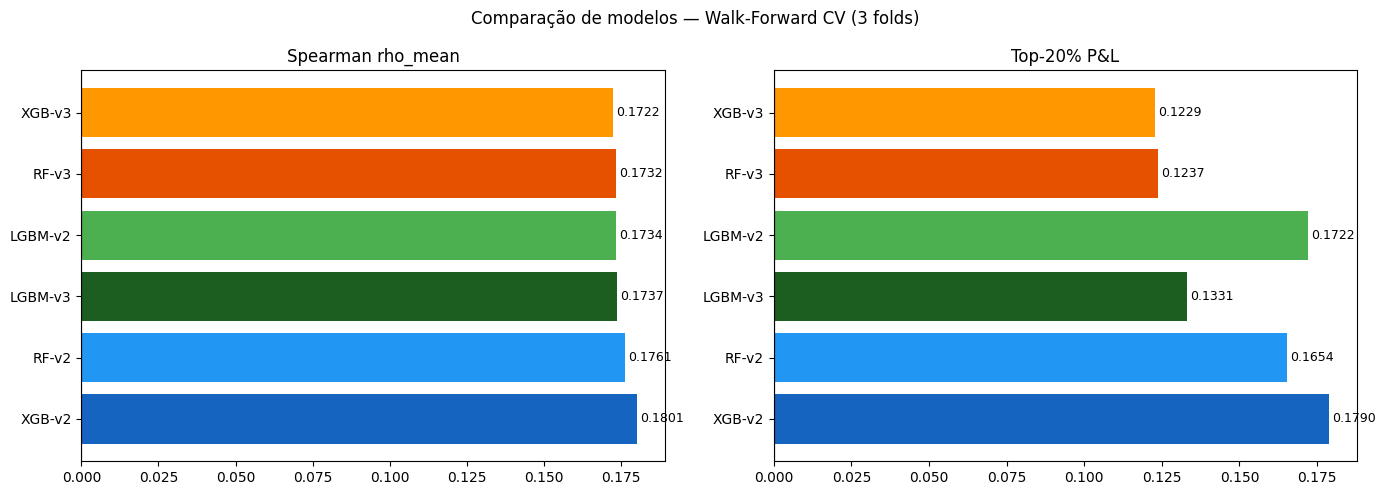

In [ ]:
summary_rows = []
for name, folds in results.items():
    if not folds: continue
    df_f = pd.DataFrame(folds)
    summary_rows.append({
        'Modelo':     name,
        'n_features': len(MODEL_CONFIGS[name]['feat']),
        'rho_up':     df_f['rho_up'].mean(),
        'rho_down':   df_f['rho_down'].mean(),
        'rho_mean':   df_f['rho_mean'].mean(),
        'rho_std':    df_f['rho_mean'].std(),
        'topk_pnl':   df_f['topk_pnl'].mean(),
    })

df_summary = pd.DataFrame(summary_rows).sort_values('rho_mean', ascending=False)
print('=== Walk-Forward CV — média dos 5 folds ===')
print(df_summary.to_string(index=False))

CHAMPION_NAME = df_summary.sort_values(['rho_mean', 'topk_pnl'], ascending=False).iloc[0]['Modelo']
champ_row     = df_summary[df_summary['Modelo'] == CHAMPION_NAME].iloc[0]
print(f'\n🏆 Champion: {CHAMPION_NAME}')
print(f'   rho_mean  = {champ_row["rho_mean"]:.4f}  {"✅" if champ_row["rho_mean"] >= 0.10 else "⚠️  < 0.10"}')
print(f'   topk_pnl  = {champ_row["topk_pnl"]:.4f}  {"✅" if champ_row["topk_pnl"] >= 0.05 else "⚠️  < 0.05"}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#1565C0', '#2196F3', '#1B5E20', '#4CAF50', '#E65100', '#FF9800']
models_sorted = df_summary['Modelo'].tolist()
for ax, col, title in [(ax1, 'rho_mean', 'Spearman rho_mean'), (ax2, 'topk_pnl', 'Top-20% P&L')]:
    vals = df_summary[col].tolist()
    bars = ax.barh(models_sorted, vals, color=colors[:len(models_sorted)])
    ax.axvline(0, color='black', lw=0.8); ax.set_title(title)
    for bar, v in zip(bars, vals):
        ax.text(v + 0.001, bar.get_y() + bar.get_height()/2, f'{v:.4f}', va='center', fontsize=9)
plt.suptitle('Comparação de modelos — Walk-Forward CV (3 folds)', fontsize=12)
plt.tight_layout(); plt.show()

---
## 🏋️ FASE D — Treino final do champion
---

## 10 · Treinar champion no dataset completo

A treinar XGB-v2 — 17303 amostras, 17 features...
✅ Treino concluído.


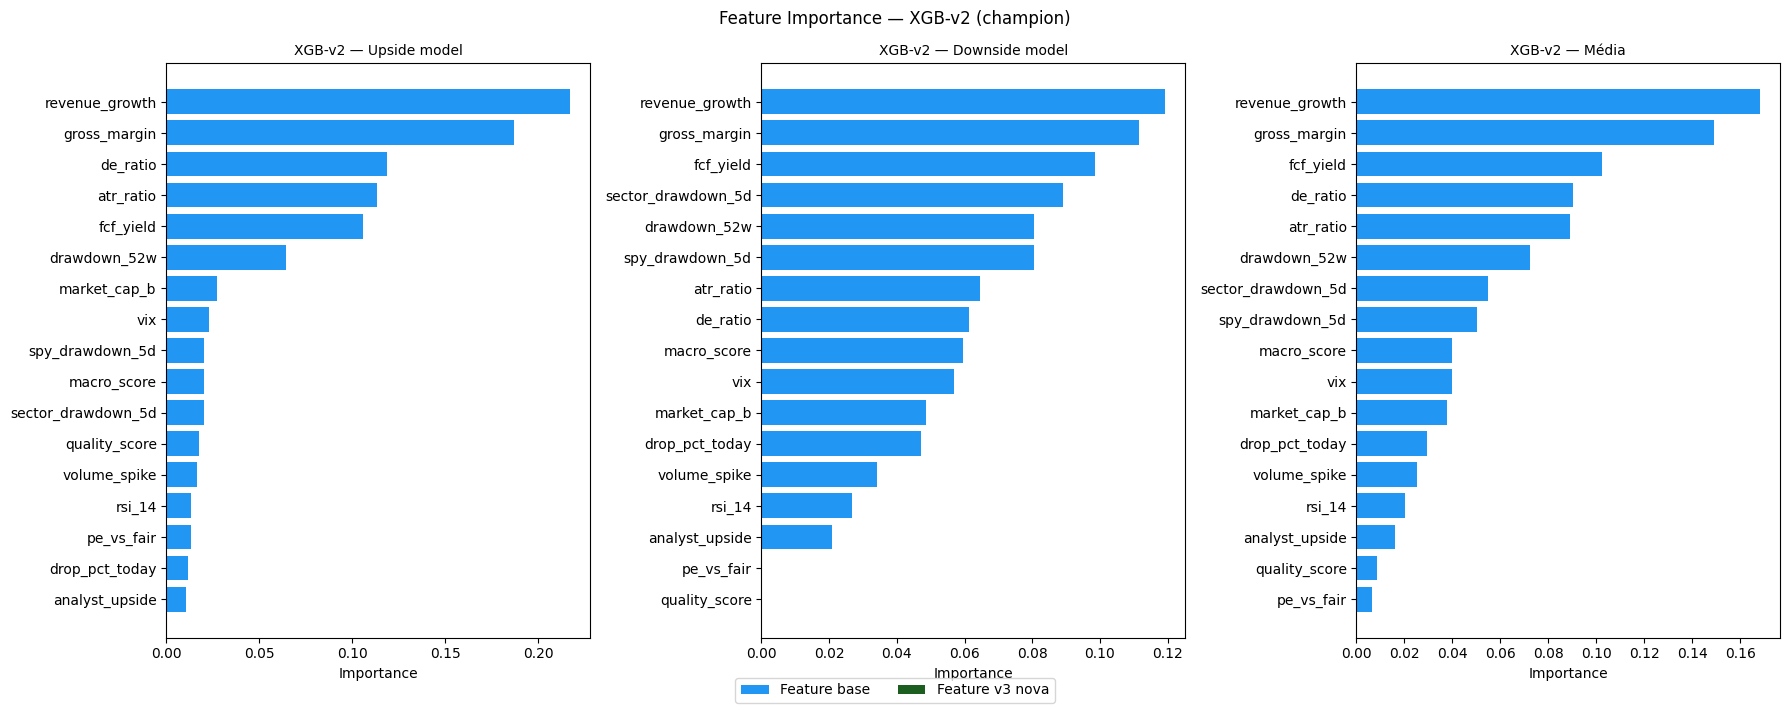


Top 10 features (média):
revenue_growth       0.1682
gross_margin         0.1493
fcf_yield            0.1023
de_ratio             0.0901
atr_ratio            0.0890
drawdown_52w         0.0724
sector_drawdown_5d   0.0547
spy_drawdown_5d      0.0504
macro_score          0.0400
vix                  0.0399


In [ ]:
champion_cfg   = MODEL_CONFIGS[CHAMPION_NAME]
champion_feats = [f for f in champion_cfg['feat'] if f in df_v3.columns]

X_full    = df_v3[champion_feats].fillna(0).values.astype(np.float32)
y_up_full = winsorize(df_v3['max_return_60d'].fillna(0).values)
y_dn_full = winsorize(df_v3['max_drawdown_60d'].fillna(0).values)
y_up_t, y_dn_t = transform_targets(y_up_full, y_dn_full)

print(f'A treinar {CHAMPION_NAME} — {len(X_full)} amostras, {len(champion_feats)} features...')
champ_up   = champion_cfg['up']()
champ_down = champion_cfg['down']()
champ_up.fit(X_full,   y_up_t)
champ_down.fit(X_full, y_dn_t)
print('✅ Treino concluído.')

def get_importance(model, feat_names):
    if hasattr(model, 'feature_importances_'):
        return pd.Series(model.feature_importances_, index=feat_names).sort_values(ascending=False)
    return pd.Series(np.zeros(len(feat_names)), index=feat_names)

imp_up   = get_importance(champ_up,   champion_feats)
imp_down = get_importance(champ_down, champion_feats)
imp_mean = ((imp_up + imp_down) / 2).sort_values(ascending=False)

from matplotlib.patches import Patch
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, imp, title in zip(axes, [imp_up, imp_down, imp_mean], ['Upside model', 'Downside model', 'Média']):
    top  = imp.head(20)
    cols = ['#1B5E20' if f in MOMENTUM_FEATURES else '#2196F3' for f in top.index]
    ax.barh(top.index[::-1], top.values[::-1], color=cols[::-1])
    ax.set_title(f'{CHAMPION_NAME} — {title}', fontsize=10)
    ax.set_xlabel('Importance')
legend_elements = [Patch(facecolor='#2196F3', label='Feature base'),
                   Patch(facecolor='#1B5E20', label='Feature v3 nova')]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.02))
plt.suptitle(f'Feature Importance — {CHAMPION_NAME} (champion)', fontsize=12)
plt.tight_layout(); plt.show()
print('\nTop 10 features (média):')
print(imp_mean.head(10).to_string())

---
## 💾 FASE E — Guardar modelo + deploy Railway
---

## 11 · Guardar dip_models_v3.pkl + ml_report_v3.json no Drive

In [ ]:
from dataclasses import dataclass

@dataclass
class DipModelsV3:
    model_up:         object
    model_down:       object
    feature_cols:     list
    momentum_feats:   list
    n_train_samples:  int
    train_date:       str
    champion_name:    str
    schema_version:   int = 3

bundle = DipModelsV3(
    model_up        = champ_up,
    model_down      = champ_down,
    feature_cols    = champion_feats,
    momentum_feats  = MOMENTUM_FEATURES,
    n_train_samples = int(len(X_full)),
    train_date      = datetime.utcnow().strftime('%Y-%m-%dT%H:%M:%SZ'),
    champion_name   = CHAMPION_NAME,
)

with open(MODEL_OUT, 'wb') as f:
    pickle.dump(bundle, f)
print(f'✅ Modelo guardado: {MODEL_OUT}')

report = {
    'schema_version':    3,
    'trained_at':        bundle.train_date,
    'champion_model':    CHAMPION_NAME,
    'n_features':        len(champion_feats),
    'n_train_samples':   int(len(X_full)),
    'feature_cols':      champion_feats,
    'momentum_features': MOMENTUM_FEATURES,
    'walk_forward_cv': {
        'n_folds':       N_FOLDS,
        'rho_up_mean':   float(champ_row['rho_up']),
        'rho_down_mean': float(champ_row['rho_down']),
        'rho_mean':      float(champ_row['rho_mean']),
        'rho_std':       float(champ_row['rho_std']),
        'topk_pnl_mean': float(champ_row['topk_pnl']),
    },
    'all_models':    df_summary[['Modelo', 'rho_mean', 'topk_pnl']].to_dict(orient='records'),
    'top_features':  imp_mean.head(15).to_dict(),
    'dataset_stats': {
        'n_samples':         int(len(df_v3)),
        'win_rate':          float(df_v3['label_win'].mean()),
        'max_return_mean':   float(df_v3['max_return_60d'].mean()),
        'max_return_std':    float(df_v3['max_return_60d'].std()),
        'max_drawdown_mean': float(df_v3['max_drawdown_60d'].mean()),
        'max_drawdown_std':  float(df_v3['max_drawdown_60d'].std()),
    },
    'passes_validation': {
        'rho_mean_gte_010': bool(champ_row['rho_mean'] >= 0.10),
        'topk_pnl_gte_005': bool(champ_row['topk_pnl'] >= 0.05),
    },
}

with open(REPORT_OUT, 'w') as f:
    json.dump(report, f, indent=2)
print(f'✅ Report guardado: {REPORT_OUT}')
print()
print(json.dumps(report['walk_forward_cv'], indent=2))
print(json.dumps(report['passes_validation'], indent=2))

✅ Modelo guardado: /content/drive/MyDrive/DipRadar/dip_models_v3.pkl
✅ Report guardado: /content/drive/MyDrive/DipRadar/ml_report_v3.json

{
  "n_folds": 5,
  "rho_up_mean": 0.36118184809546633,
  "rho_down_mean": -0.0010810178079194435,
  "rho_mean": 0.18005041514377343,
  "rho_std": 0.032461704987060844,
  "topk_pnl_mean": 0.17895082125290016
}
{
  "rho_mean_gte_010": true,
  "topk_pnl_gte_005": true
}


## 12 · Verificar ficheiros no Drive

In [ ]:
print('📁 Ficheiros no Drive (DipRadar):')
for f in sorted(DRIVE_DIR.iterdir()):
    print(f'  {f.name:<40} {f.stat().st_size/1024:>8.1f} KB')

📁 Ficheiros no Drive (DipRadar):
  dataset_v3.parquet                         1889.8 KB
  dip_model_price.pkl                       15263.0 KB
  dip_model_stage1.pkl                      13345.7 KB
  dip_model_stage2.pkl                       2390.5 KB
  dip_models_v3.pkl                           918.1 KB
  ml_report.json                                7.7 KB
  ml_report_v3.json                             2.5 KB
  ml_training_fund.parquet                    309.6 KB
  ml_training_merged.parquet                  926.6 KB
  ml_training_price.parquet                   718.8 KB


## 13 · Deploy para Railway

### Opção A — Railway Volume (recomendado)
```bash
railway volume cp ./dip_models_v3.pkl /data/dip_models_v3.pkl
railway volume cp ./ml_report_v3.json /data/ml_report_v3.json
```

### Opção B — Commit directo (só se < 50 MB)
```bash
git add dip_models_v3.pkl ml_report_v3.json
git commit -m 'feat: modelo v3 regression'
git push
```

### Validação pós-deploy
```python
import pickle
bundle = pickle.load(open('/data/dip_models_v3.pkl', 'rb'))
assert bundle.schema_version == 3
assert hasattr(bundle, 'model_up') and hasattr(bundle, 'model_down')
print(f'✅ {bundle.champion_name}  {len(bundle.feature_cols)} features  {bundle.train_date}')
```

### TESTES

In [33]:
# No colab_bootstrap.ipynb
spearman_up_only = spearmanr(score_up_only, actual_return).correlation
spearman_ratio   = spearmanr(score_ratio,   actual_return).correlation
# Se delta < 0.02 → downside model irrelevante

NameError: name 'score_up_only' is not defined

In [ ]:
capital = 100_000
max_concurrent = 10        # máx 10 posições simultâneas
position_size  = capital / max_concurrent
hold_days = 60

# Para cada alerta (ordenado por data):
#   Se score > threshold E posições abertas < 10:
#     abre posição equally weighted
#     fecha em t+60
# → calcula equity curve, drawdown, Sharpe